In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/customer-churn"

folders = [
    "data",
    "notebooks",
    "src",
    "models",
    "app"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created!")

Folders created!


In [3]:
!pip install kaggle

In [4]:
!kaggle datasets download -d blastchar/telco-customer-churn
!unzip telco-customer-churn.zip -d /content/drive/MyDrive/customer-churn/data

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 40.2MB/s]

Archive:  telco-customer-churn.zip
replace /content/drive/MyDrive/customer-churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/drive/MyDrive/customer-churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [5]:
import pandas as pd

file_path = "/content/drive/MyDrive/customer-churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.dropna(inplace=True)

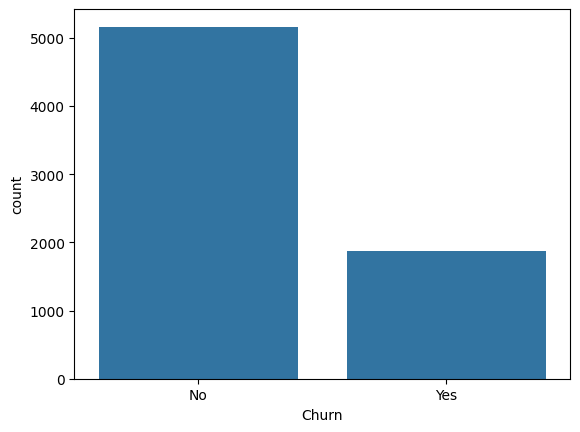

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

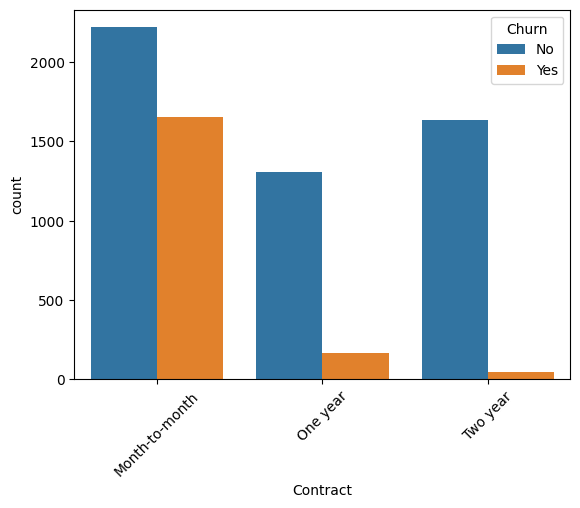

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

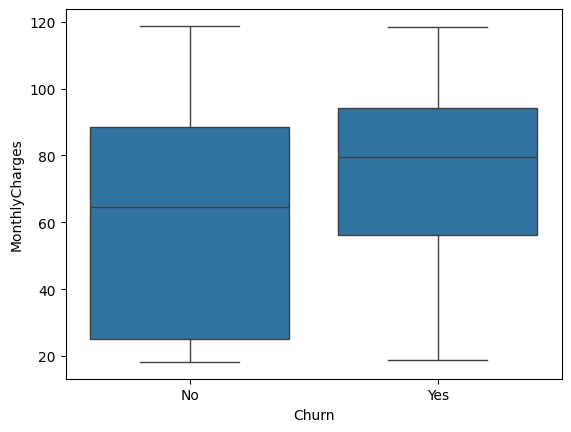

In [11]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

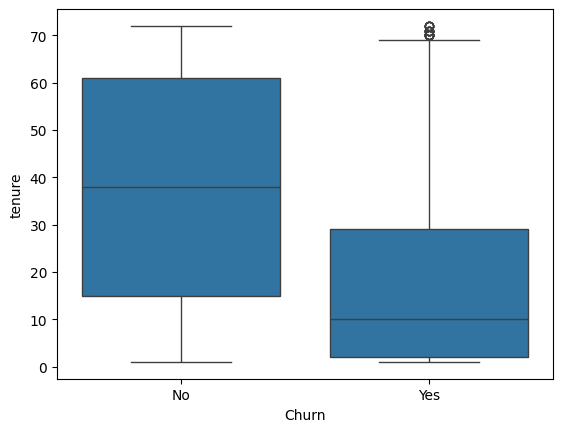

In [12]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

In [14]:
with open("/content/drive/MyDrive/customer-churn/src/preprocess.py", "r") as f:
    print(f.read())

{"nbformat":4,"nbformat_minor":0,"metadata":{"colab":{"provenance":[],"authorship_tag":"ABX9TyNPBBjjWFldZt0iTBc99fvs"},"kernelspec":{"name":"python3","display_name":"Python 3"},"language_info":{"name":"python"}},"cells":[{"cell_type":"code","source":["import os\n","\n","os.makedirs(\"/content/drive/MyDrive/customer-churn/src\", exist_ok=True)"],"metadata":{"id":"SOYMyyakBCcm","executionInfo":{"status":"ok","timestamp":1777698312017,"user_tz":-330,"elapsed":11,"user":{"displayName":"Hriteeka Singh","userId":"10489573442744853010"}}},"execution_count":2,"outputs":[]},{"cell_type":"code","source":["%%writefile /content/drive/MyDrive/customer-churn/src/preprocess.py\n","import pandas as pd\n","\n","def load_data(path):\n","    df = pd.read_csv(path)\n","    return df\n","\n","def clean_data(df):\n","    df[\"TotalCharges\"] = pd.to_numeric(df[\"TotalCharges\"], errors='coerce')\n","    df.dropna(inplace=True)\n","    df.drop(\"customerID\", axis=1, inplace=True)\n","    return df"],"metada

In [17]:
import os

file_path = "/content/drive/MyDrive/customer-churn/src/preprocess.py"

if os.path.exists(file_path):
    os.remove(file_path)
    print("Old file deleted")
else:
    print("File not found")

Old file deleted


In [18]:
%%writefile /content/drive/MyDrive/customer-churn/src/preprocess.py
import pandas as pd

def load_data(path):
    df = pd.read_csv(path)
    return df

def clean_data(df):
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
    df.dropna(inplace=True)
    df.drop("customerID", axis=1, inplace=True)
    return df

Writing /content/drive/MyDrive/customer-churn/src/preprocess.py


In [19]:
with open("/content/drive/MyDrive/customer-churn/src/preprocess.py", "r") as f:
    print(f.read())

import pandas as pd

def load_data(path):
    df = pd.read_csv(path)
    return df

def clean_data(df):
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
    df.dropna(inplace=True)
    df.drop("customerID", axis=1, inplace=True)
    return df



In [21]:
import os

files = [
    "/content/drive/MyDrive/customer-churn/src/train.py",
    "/content/drive/MyDrive/customer-churn/src/evaluate.py"
]

for file in files:
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"Not found: {file}")

Deleted: /content/drive/MyDrive/customer-churn/src/train.py
Deleted: /content/drive/MyDrive/customer-churn/src/evaluate.py


In [22]:
%%writefile /content/drive/MyDrive/customer-churn/src/train.py
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

def train_models(X_train, y_train):
    models = {}

    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    models["logistic_regression"] = lr

    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    models["random_forest"] = rf

    xgb = XGBClassifier()
    xgb.fit(X_train, y_train)
    models["xgboost"] = xgb

    return models

Writing /content/drive/MyDrive/customer-churn/src/train.py


In [23]:
%%writefile /content/drive/MyDrive/customer-churn/src/evaluate.py
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def evaluate_models(models, X_test, y_test):
    results = {}

    for name, model in models.items():
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_pred)

        print(f"\n{name.upper()} RESULTS")
        print("Accuracy:", acc)
        print("ROC-AUC:", roc)
        print(classification_report(y_test, y_pred))

        results[name] = {
            "accuracy": acc,
            "roc_auc": roc
        }

    return results

Writing /content/drive/MyDrive/customer-churn/src/evaluate.py


In [24]:
for file in files:
    print(f"\n--- {file} ---\n")
    with open(file, "r") as f:
        print(f.read())


--- /content/drive/MyDrive/customer-churn/src/train.py ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

def train_models(X_train, y_train):
    models = {}

    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    models["logistic_regression"] = lr

    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    models["random_forest"] = rf

    xgb = XGBClassifier()
    xgb.fit(X_train, y_train)
    models["xgboost"] = xgb

    return models


--- /content/drive/MyDrive/customer-churn/src/evaluate.py ---

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

def evaluate_models(models, X_test, y_test):
    results = {}

    for name, model in models.items():
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_pred)

        print(f"\n{name.upper()} RESULTS")
        print("Accuracy:",

In [25]:
import sys
sys.path.append("/content/drive/MyDrive/customer-churn")

from src.preprocess import load_data, clean_data
from src.train import train_models
from src.evaluate import evaluate_models

In [26]:
# Load data
file_path = "/content/drive/MyDrive/customer-churn/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = load_data(file_path)

# Clean data
df = clean_data(df)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train models
models = train_models(X_train, y_train)

# Evaluate models
results = evaluate_models(models, X_test, y_test)


LOGISTIC_REGRESSION RESULTS
Accuracy: 0.7853589196872779
ROC-AUC: 0.6926311402850324
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407


RANDOM_FOREST RESULTS
Accuracy: 0.7839374555792467
ROC-AUC: 0.6848401157523645
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407


XGBOOST RESULTS
Accuracy: 0.7640369580668088
ROC-AUC: 0.6755517132488831
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      10

In [27]:
!pip install imbalanced-learn

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [29]:
models = train_models(X_train_smote, y_train_smote)
results = evaluate_models(models, X_test, y_test)


LOGISTIC_REGRESSION RESULTS
Accuracy: 0.7356076759061834
ROC-AUC: 0.7559765699820366
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407


RANDOM_FOREST RESULTS
Accuracy: 0.7746979388770433
ROC-AUC: 0.7101040011181803
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


XGBOOST RESULTS
Accuracy: 0.7583511016346838
ROC-AUC: 0.6981185064010642
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      10

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

rf_model = models["random_forest"]

feature_importances = rf_model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

             Feature  Importance
14          Contract    0.152436
17    MonthlyCharges    0.134065
18      TotalCharges    0.133693
4             tenure    0.131184
16     PaymentMethod    0.074911
8     OnlineSecurity    0.062144
11       TechSupport    0.058942
7    InternetService    0.035936
15  PaperlessBilling    0.028422
9       OnlineBackup    0.026637


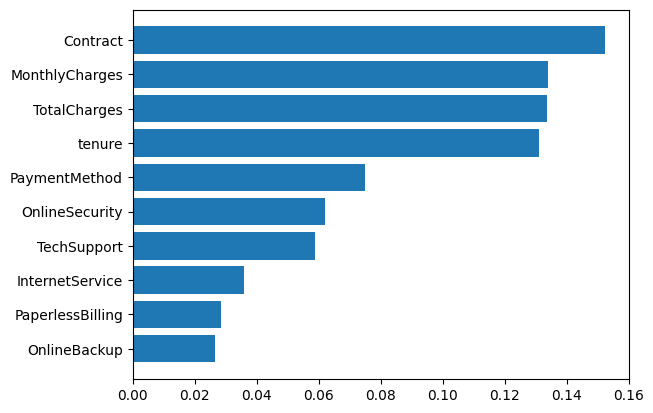

In [31]:
plt.figure()
plt.barh(importance_df["Feature"][:10], importance_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='roc_auc')
grid.fit(X_train_smote, y_train_smote)

best_lr = grid.best_estimator_

In [33]:
evaluate_models({"tuned_logistic": best_lr}, X_test, y_test)


TUNED_LOGISTIC RESULTS
Accuracy: 0.7356076759061834
ROC-AUC: 0.7559765699820366
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



{'tuned_logistic': {'accuracy': 0.7356076759061834,
  'roc_auc': np.float64(0.7559765699820366)}}

In [34]:
import joblib
joblib.dump(best_lr, "/content/drive/MyDrive/customer-churn/models/best_model.pkl")

['/content/drive/MyDrive/customer-churn/models/best_model.pkl']

In [35]:
import joblib
joblib.dump(best_lr, "/content/drive/MyDrive/customer-churn/models/best_model.pkl")

['/content/drive/MyDrive/customer-churn/models/best_model.pkl']